In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Analysing Data

In [4]:
test_data=pd.read_csv('/content/drive/MyDrive/Kaggle Playground/test.csv')

In [5]:
test_data

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254650,848844,Male,0,Yes,Yes,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.95,1443.65
254651,848845,Male,1,Yes,No,16,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,100.15,1563.50
254652,848846,Male,0,Yes,No,35,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),105.80,3132.75
254653,848847,Female,0,No,No,25,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.25,511.25


In [6]:
sample_subission_data=pd.read_csv('/content/drive/MyDrive/Kaggle Playground/sample_submission.csv')
sample_subission_data

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0
...,...,...
254650,848844,0
254651,848845,0
254652,848846,0
254653,848847,0


In [7]:
train_data = pd.read_csv('/content/drive/MyDrive/Kaggle Playground/train.csv')
train_data

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No


In [8]:
train_data.isnull().sum()

,0
id,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
train_data.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
train_data['PhoneService'].value_counts()

,count
PhoneService,
Yes,557893
No,36301


In [11]:
yes_no_columns=['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'PaperlessBilling']
for i in yes_no_columns:
  print(train_data[i].value_counts())
  print('\n')

Partner
Yes    309554
No     284640
Name: count, dtype: int64


Dependents
No     414362
Yes    179832
Name: count, dtype: int64


PhoneService
Yes    557893
No      36301
Name: count, dtype: int64


MultipleLines
No                  283384
Yes                 274509
No phone service     36301
Name: count, dtype: int64


OnlineSecurity
No                     289474
Yes                    163993
No internet service    140727
Name: count, dtype: int64


OnlineBackup
No                     250083
Yes                    203384
No internet service    140727
Name: count, dtype: int64


DeviceProtection
No                     247377
Yes                    206090
No internet service    140727
Name: count, dtype: int64


TechSupport
No                     288571
Yes                    164896
No internet service    140727
Name: count, dtype: int64


StreamingTV
Yes                    240301
No                     213166
No internet service    140727
Name: count, dtype: int64


StreamingMovies
Ye

In [12]:
train_data.replace('No internet service', 'No', inplace=True)
train_data.replace('No phone service', 'No', inplace=True)

# Convert 'Yes'/'No' to 1/0 for relevant columns
for col in yes_no_columns:
    train_data[col] = train_data[col].apply(lambda x: 1 if x == 'Yes' else 0)

# Convert 'gender' to numerical
train_data['gender'] = train_data['gender'].apply(lambda x: 1 if x == 'Male' else 0)

# Convert 'Churn' to numerical (target variable)
train_data['Churn'] = train_data['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

display(train_data.head())

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,0,1,1,29,1,0,DSL,1,...,1,1,0,0,One year,1,Mailed check,60.10,1653.85,0
1,1,1,0,1,1,58,1,0,DSL,1,...,0,1,1,0,Two year,0,Credit card (automatic),69.50,3778.20,0
2,2,1,0,1,0,58,1,1,Fiber optic,0,...,0,0,1,1,Month-to-month,1,Electronic check,100.40,5841.35,0
3,3,0,0,0,0,1,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,69.70,70.70,1
4,4,0,0,0,0,1,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.45,70.45,1


Now, let's apply one-hot encoding to the remaining categorical columns: `InternetService`, `Contract`, and `PaymentMethod`.

In [13]:
categorical_cols = ['InternetService', 'Contract', 'PaymentMethod']
train_data = pd.get_dummies(train_data, columns=categorical_cols, drop_first=True)
display(train_data.head())

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,1,29,1,0,1,0,...,60.10,1653.85,0,False,False,True,False,False,False,True
1,1,1,0,1,1,58,1,0,1,1,...,69.50,3778.20,0,False,False,False,True,True,False,False
2,2,1,0,1,0,58,1,1,0,1,...,100.40,5841.35,0,True,False,False,False,False,True,False
3,3,0,0,0,0,1,1,0,0,0,...,69.70,70.70,1,True,False,False,False,False,True,False
4,4,0,0,0,0,1,1,0,0,0,...,70.45,70.45,1,True,False,False,False,False,True,False


Finally, let's also ensure `TotalCharges` is a numeric type. It often gets loaded as an object type due to empty strings or other non-numeric values. We'll convert it to numeric, coercing errors to NaN, and then fill any NaNs with 0 (or another appropriate strategy if needed).

In [14]:
train_data['TotalCharges'] = pd.to_numeric(train_data['TotalCharges'], errors='coerce')
train_data['TotalCharges'].fillna(0, inplace=True)
display(train_data)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,1,29,1,0,1,0,...,60.10,1653.85,0,False,False,True,False,False,False,True
1,1,1,0,1,1,58,1,0,1,1,...,69.50,3778.20,0,False,False,False,True,True,False,False
2,2,1,0,1,0,58,1,1,0,1,...,100.40,5841.35,0,True,False,False,False,False,True,False
3,3,0,0,0,0,1,1,0,0,0,...,69.70,70.70,1,True,False,False,False,False,True,False
4,4,0,0,0,0,1,1,0,0,0,...,70.45,70.45,1,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,594189,1,0,0,0,57,1,1,0,0,...,97.55,5460.70,0,True,False,False,True,False,False,False
594190,594190,0,0,0,0,72,1,1,1,1,...,91.95,6782.15,0,False,False,False,True,False,False,False
594191,594191,0,0,1,0,72,1,1,0,0,...,24.40,1871.90,0,False,True,False,True,True,False,False
594192,594192,0,0,0,0,32,1,1,0,0,...,86.00,2847.20,0,True,False,False,False,False,True,False


In [15]:
bool_cols = train_data.select_dtypes(include='bool').columns
train_data[bool_cols] = train_data[bool_cols].astype(int)

display(train_data.head())

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,1,29,1,0,1,0,...,60.10,1653.85,0,0,0,1,0,0,0,1
1,1,1,0,1,1,58,1,0,1,1,...,69.50,3778.20,0,0,0,0,1,1,0,0
2,2,1,0,1,0,58,1,1,0,1,...,100.40,5841.35,0,1,0,0,0,0,1,0
3,3,0,0,0,0,1,1,0,0,0,...,69.70,70.70,1,1,0,0,0,0,1,0
4,4,0,0,0,0,1,1,0,0,0,...,70.45,70.45,1,1,0,0,0,0,1,0


<Axes: >

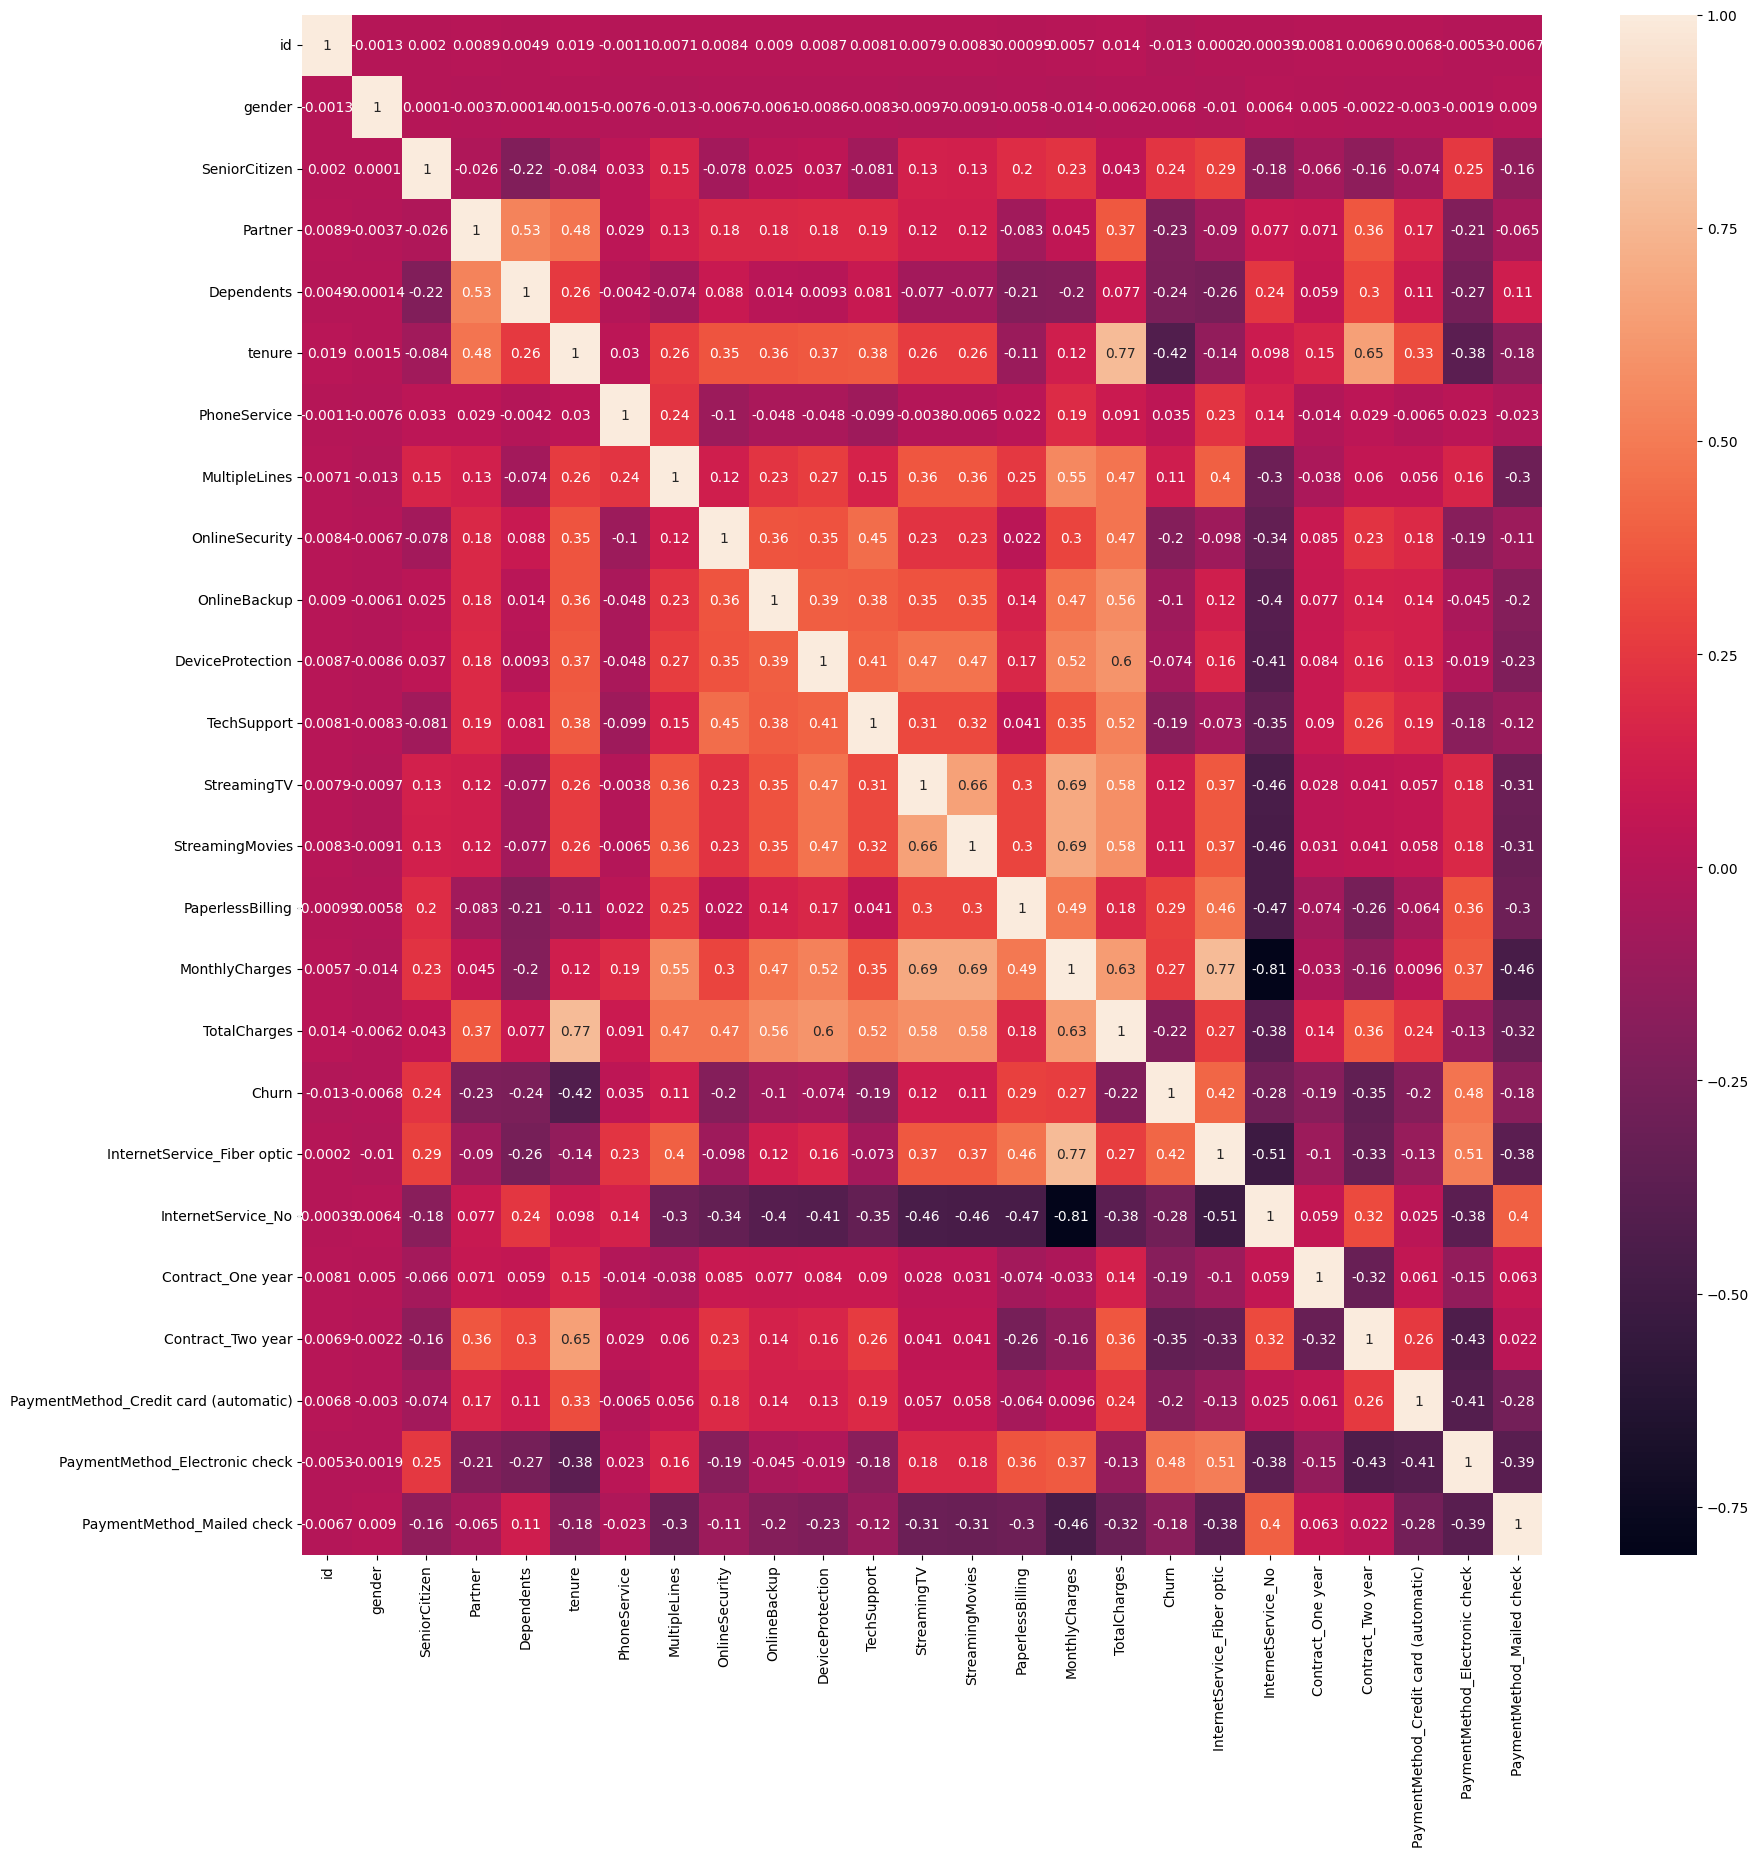

In [16]:
corr=train_data.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr,annot=True)

In [17]:
# Final check of data types and missing values
print("--- Data Types Summary ---")
print(train_data.dtypes.value_counts())

print("\n--- Columns with Non-Numeric Data ---")
print(train_data.select_dtypes(exclude=['number']).columns.tolist())

print("\n--- Missing Values Check ---")
print(train_data.isnull().sum().sum())

print("\n--- Dataset Shape ---")
print(train_data.shape)

display(train_data.head())

--- Data Types Summary ---
int64      23
float64     2
Name: count, dtype: int64

--- Columns with Non-Numeric Data ---
[]

--- Missing Values Check ---
0

--- Dataset Shape ---
(594194, 25)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,1,29,1,0,1,0,...,60.10,1653.85,0,0,0,1,0,0,0,1
1,1,1,0,1,1,58,1,0,1,1,...,69.50,3778.20,0,0,0,0,1,1,0,0
2,2,1,0,1,0,58,1,1,0,1,...,100.40,5841.35,0,1,0,0,0,0,1,0
3,3,0,0,0,0,1,1,0,0,0,...,69.70,70.70,1,1,0,0,0,0,1,0
4,4,0,0,0,0,1,1,0,0,0,...,70.45,70.45,1,1,0,0,0,0,1,0


In [18]:
train_data['Churn'].value_counts()

,count
Churn,
0,460377
1,133817


In [19]:
train_data.to_csv("clean_train_data.csv", index=False)

In [20]:
clean_df=pd.read_csv('/content/clean_train_data.csv')
clean_df.describe()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,...,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.497238,0.114102,0.520965,0.302649,36.577258,0.938907,0.461985,0.275992,0.342286,...,65.866223,2494.377057,0.225208,0.458413,0.236837,0.182319,0.314616,0.225019,0.362461,0.208277
std,171529.177262,0.499993,0.317936,0.499561,0.459405,25.061922,0.239501,0.498553,0.447013,0.474475,...,31.067444,2353.916710,0.417719,0.498268,0.425142,0.386108,0.464363,0.417595,0.480711,0.406076
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,148548.250000,0.000000,0.000000,0.000000,0.000000,12.000000,1.000000,0.000000,0.000000,0.000000,...,29.900000,639.650000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,297096.500000,0.000000,0.000000,1.000000,0.000000,35.000000,1.000000,0.000000,0.000000,0.000000,...,74.100000,1433.650000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,445644.750000,1.000000,0.000000,1.000000,1.000000,62.000000,1.000000,1.000000,1.000000,1.000000,...,90.800000,4263.800000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,594193.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,...,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Analysis from Describe

1.22.5% of customers churn

2.25% of customers have been with the company for only 12 months or less-new customers are typically high churn risk — a very common pattern in telecom

3.



<Axes: xlabel='gender', ylabel='Churn'>

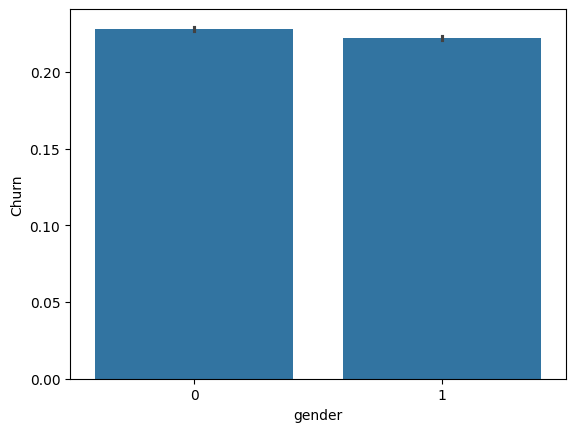

In [21]:
# Analyzing male and female relation to churn

sns.barplot(x='gender',y='Churn',data=clean_df)

<Axes: xlabel='gender', ylabel='count'>

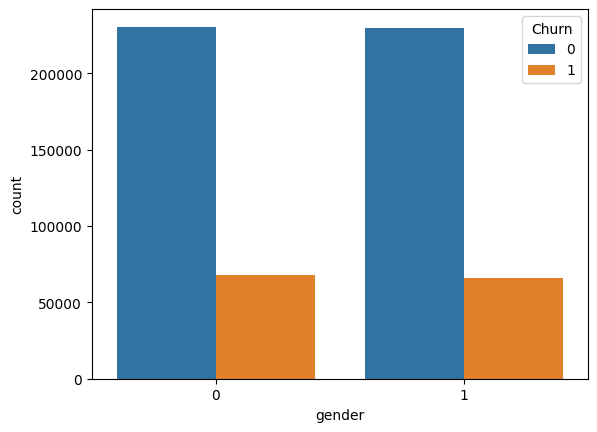

In [22]:
sns.countplot(x='gender',hue='Churn',data=clean_df)

In [23]:
print(f"Correlation between Gender and Churn: {corr['gender']['Churn']}")

Correlation between Gender and Churn: -0.006808432379763332


In [24]:
clean_df = clean_df.drop('gender', axis=1)
display(clean_df.head())

,id,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,29,1,0,1,0,1,...,60.10,1653.85,0,0,0,1,0,0,0,1
1,1,0,1,1,58,1,0,1,1,0,...,69.50,3778.20,0,0,0,0,1,1,0,0
2,2,0,1,0,58,1,1,0,1,0,...,100.40,5841.35,0,1,0,0,0,0,1,0
3,3,0,0,0,1,1,0,0,0,0,...,69.70,70.70,1,1,0,0,0,0,1,0
4,4,0,0,0,1,1,0,0,0,0,...,70.45,70.45,1,1,0,0,0,0,1,0


<Axes: xlabel='Partner', ylabel='count'>

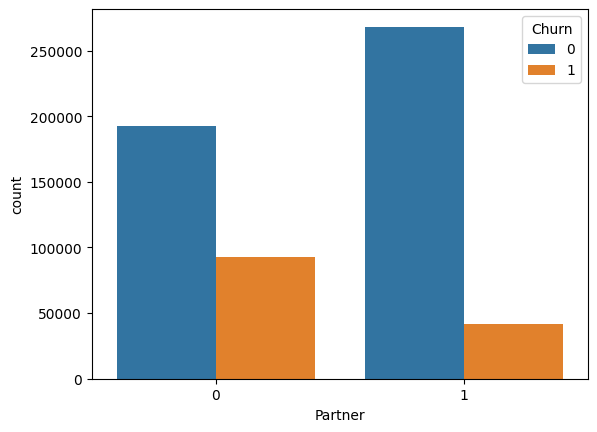

In [25]:
sns.countplot(x='Partner',hue='Churn',data=clean_df)

# If someone has no partner then he is more likely to churn and if somehas a partner than there is a little bit less prediction that he will churn

In [26]:
partner_churn_rate = clean_df.groupby('Partner')['Churn'].value_counts(normalize=True).unstack()
partner_churn_rate.columns = ['No Churn', 'Churn']
display(partner_churn_rate)

,No Churn,Churn
Partner,,
0,0.675379,0.324621
1,0.866204,0.133796


If the partner is not there then 32.4 % probability to churn but if it is present then the probability is 13.37 %

#

<Axes: xlabel='SeniorCitizen', ylabel='count'>

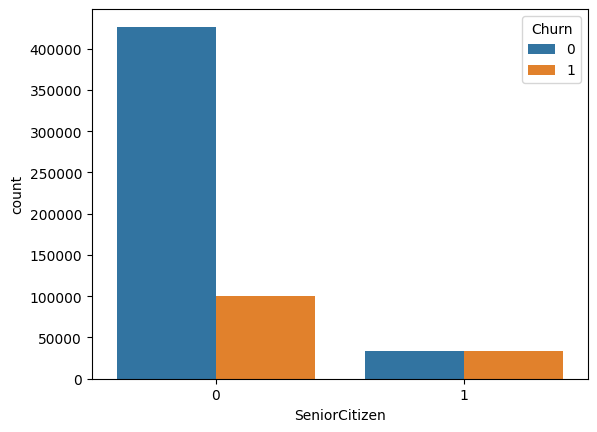

In [27]:
sns.countplot(x='SeniorCitizen',hue='Churn',data=clean_df)

<Axes: xlabel='SeniorCitizen', ylabel='Churn'>

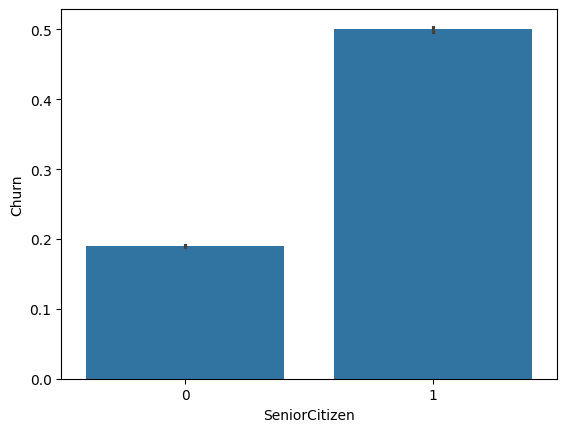

In [28]:
sns.barplot(x='SeniorCitizen',y='Churn',data=clean_df)

In [29]:
senior_citizen_churn_rate = clean_df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack()
senior_citizen_churn_rate.columns = ['No Churn', 'Churn']
display(senior_citizen_churn_rate)
print(f"\nCorrelation between SeniorCitizen and Churn: {corr['SeniorCitizen']['Churn']}")

,No Churn,Churn
SeniorCitizen,,
0,0.810226,0.189774
1,0.499683,0.500317



Correlation between SeniorCitizen and Churn: 0.23636174978353894


# Senior Citizens have a higher churn rate 50-50 % chance he will be with us or not


In [30]:
clean_df.head()

,id,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,29,1,0,1,0,1,...,60.10,1653.85,0,0,0,1,0,0,0,1
1,1,0,1,1,58,1,0,1,1,0,...,69.50,3778.20,0,0,0,0,1,1,0,0
2,2,0,1,0,58,1,1,0,1,0,...,100.40,5841.35,0,1,0,0,0,0,1,0
3,3,0,0,0,1,1,0,0,0,0,...,69.70,70.70,1,1,0,0,0,0,1,0
4,4,0,0,0,1,1,0,0,0,0,...,70.45,70.45,1,1,0,0,0,0,1,0


In [31]:
clean_df['Contract_One year'].value_counts()

,count
Contract_One year,
0,485861
1,108333


In [32]:
# Correcting the list of binary columns based on the DataFrame's structure
binary_columns = [
    'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
    'InternetService_Fiber optic', 'InternetService_No', # These are now one-hot encoded columns
    'Contract_One year', 'Contract_Two year', # These are now one-hot encoded columns
    'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'
]

print("Corrected binary columns for analysis:")
print(binary_columns)


Corrected binary columns for analysis:
['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


### How to Analyze the Plots:

For each plot, you'll see two bars for each category ('No' and 'Yes' for the binary feature), representing customers who did not churn (hue = 0) and customers who did churn (hue = 1).

Here's what to look for:

1.  **Overall Distribution:** Observe the total number of customers in each category ('No' or 'Yes' for the feature). This tells you how prevalent each characteristic is in your dataset.

2.  **Churn Rate Comparison:** Compare the height of the 'Churn=1' bar relative to the 'Churn=0' bar within each category. If the 'Churn=1' bar is significantly higher (or takes up a larger proportion of the total bar height) for one category (e.g., 'No' for a certain service), it suggests that customers in that category are more likely to churn.

    *   **High Churn in 'No' category:** If the 'No' group for a service (e.g., `OnlineSecurity`) has a proportionally higher churn count, it suggests that *not having* that service increases churn likelihood.
    *   **High Churn in 'Yes' category:** If the 'Yes' group for a service (e.g., `StreamingTV`) has a proportionally higher churn count, it suggests that *having* that service increases churn likelihood (though this is less common for beneficial services unless it's bundled or complex).

3.  **Impact on Churn:**
    *   **Features with Strong Impact:** If the churn proportion varies significantly between the 'No' and 'Yes' categories of a binary feature, that feature likely has a strong impact on churn. For example, if customers with 'Contract_Two year' rarely churn compared to 'Contract_Month-to-month' (which would be 'Contract_One year=0' and 'Contract_Two year=0'), this indicates a strong relationship.
    *   **Features with Weak Impact:** If the churn proportions are roughly similar across both 'No' and 'Yes' categories for a feature, that feature might have little influence on churn.

By systematically reviewing these plots, you can identify which binary features are strong indicators of customer churn, helping you understand the underlying reasons for churn and potentially guiding strategies to reduce it.

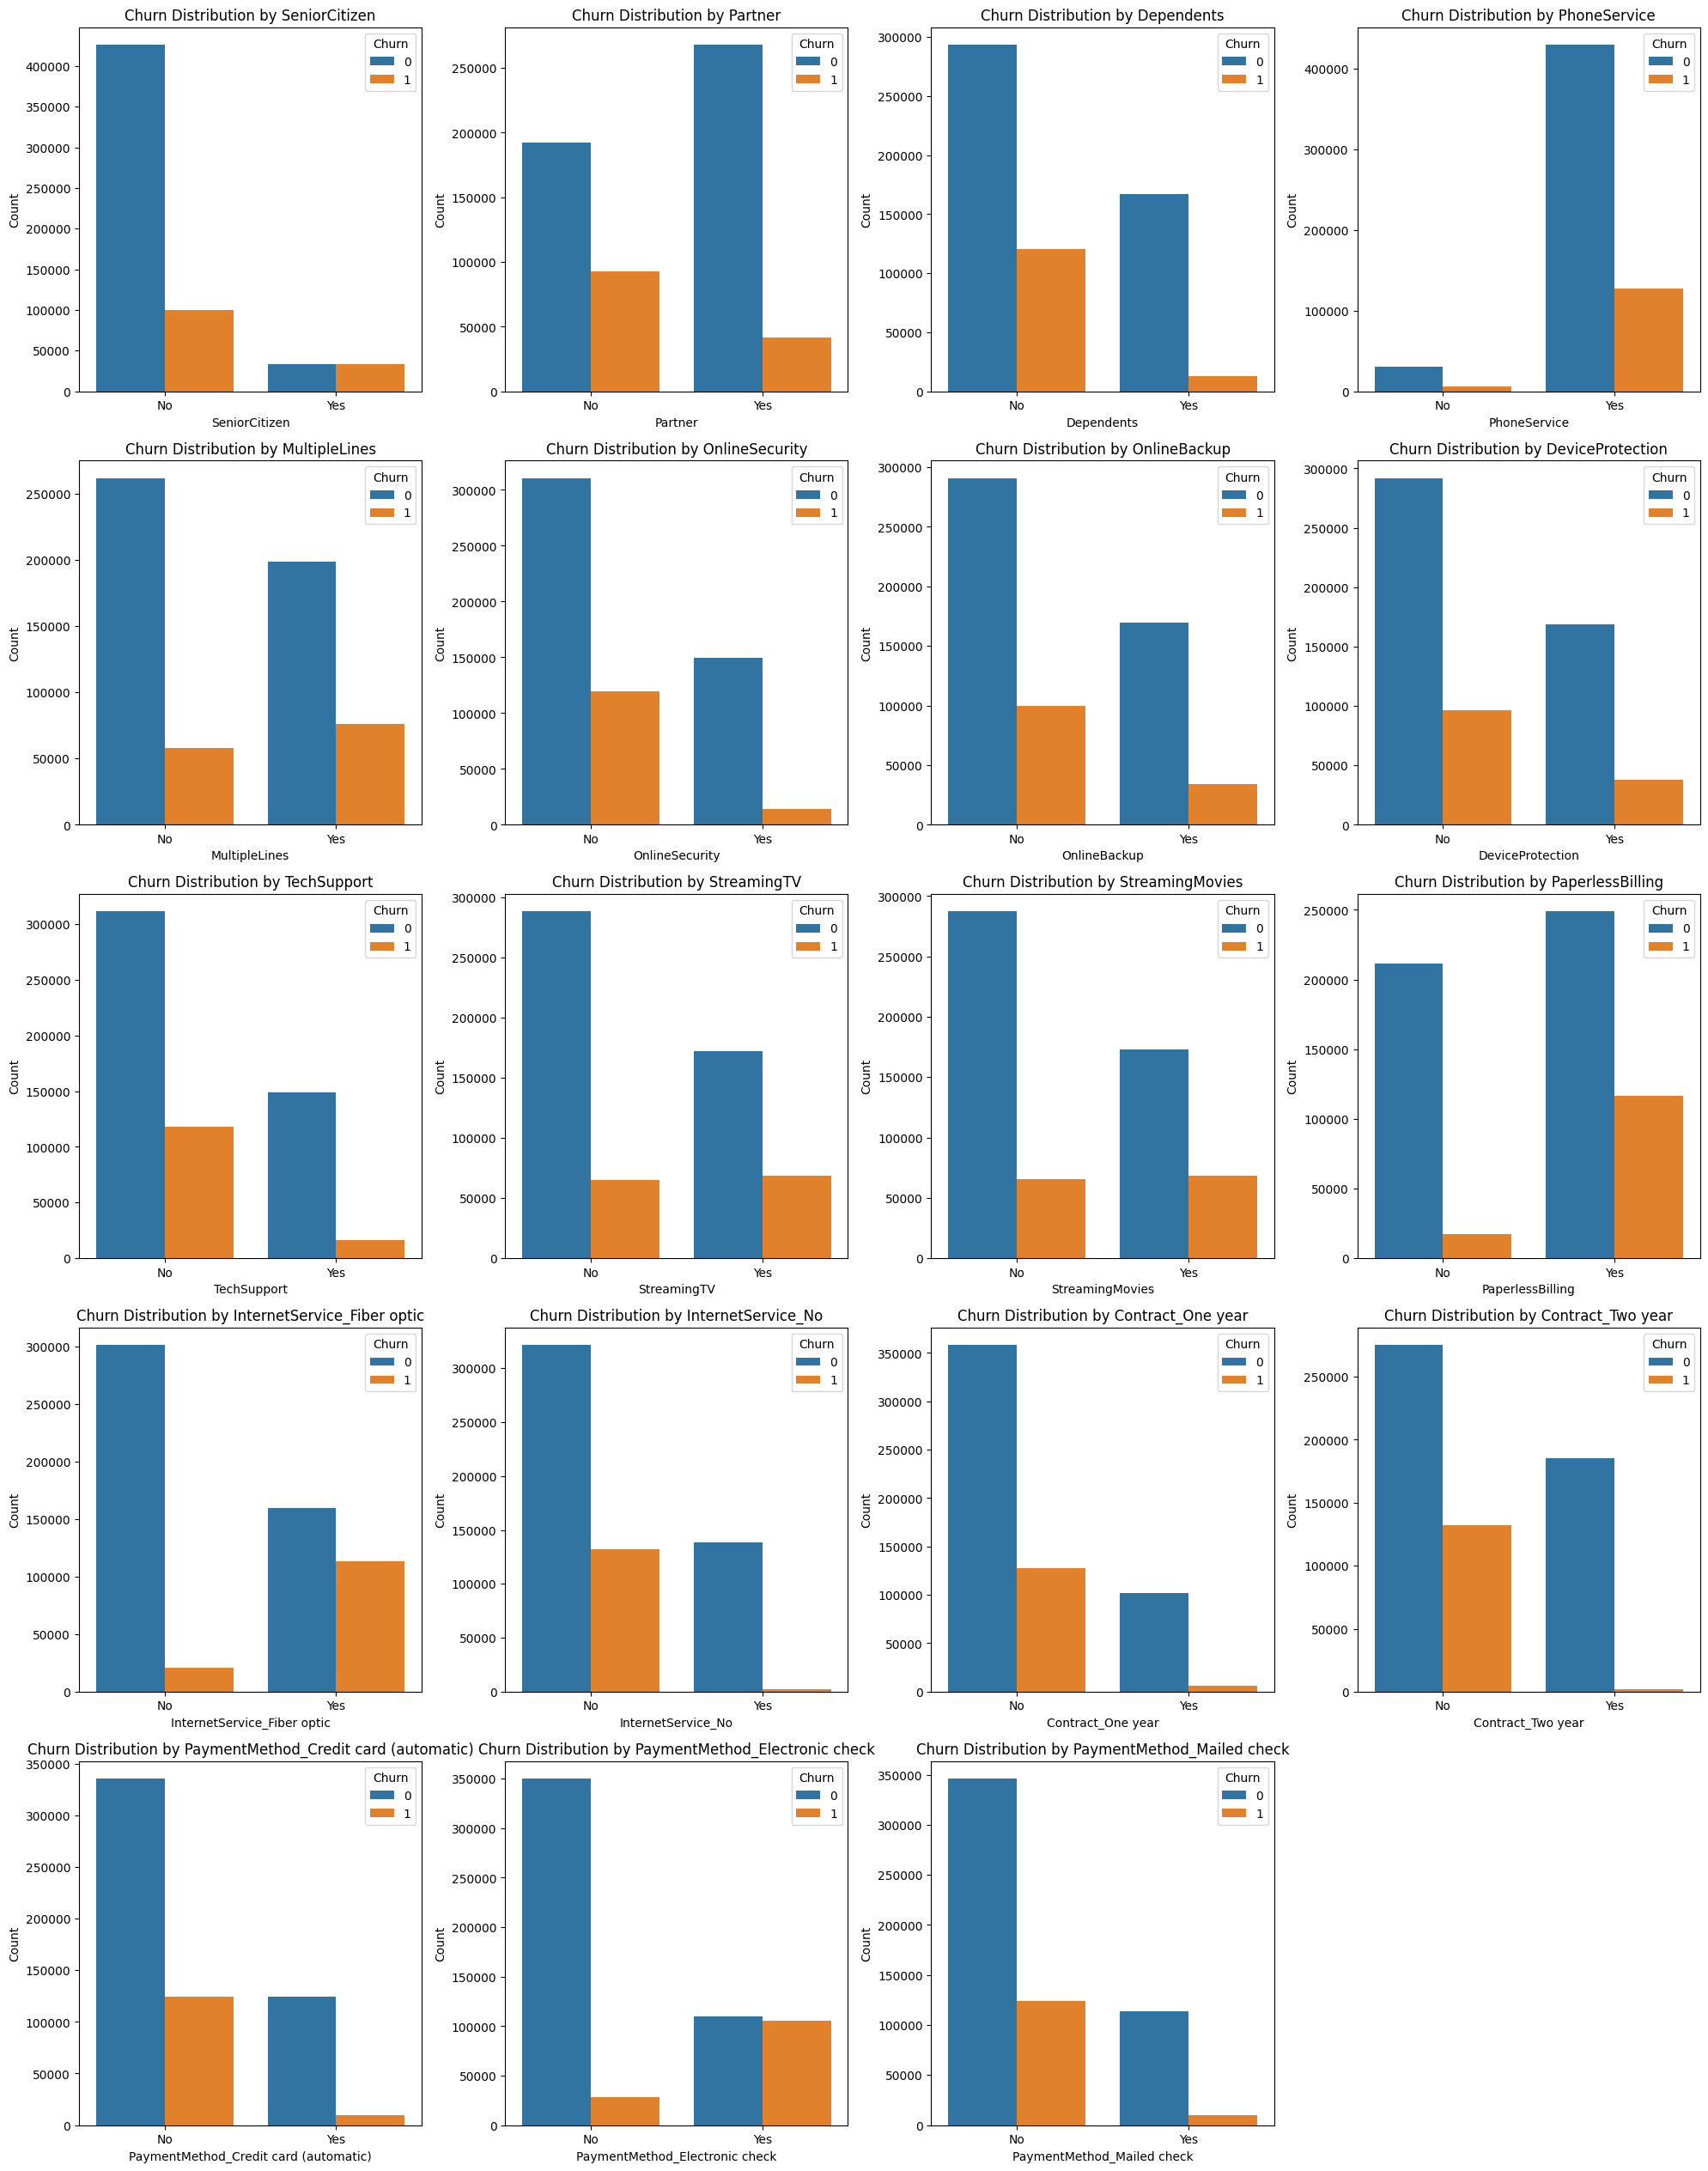

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through each corrected binary column and create a countplot
plt.figure(figsize=(20, 30))
for i, column in enumerate(binary_columns):
    plt.subplot(6, 4, i + 1) # Adjust subplot grid as needed
    sns.countplot(x=column, hue='Churn', data=clean_df)
    plt.title(f'Churn Distribution by {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(ticks=[0, 1], labels=['No', 'Yes']) # Assuming 0=No, 1=Yes for binary features
    plt.tight_layout()
plt.show()


### How to Analyze the Plots:

For each plot, you'll see two bars for each category ('No' and 'Yes' for the binary feature), representing customers who did not churn (hue = 0) and customers who did churn (hue = 1).

Here's what to look for:

1.  **Overall Distribution:** Observe the total number of customers in each category ('No' or 'Yes' for the feature). This tells you how prevalent each characteristic is in your dataset.

2.  **Churn Rate Comparison:** Compare the height of the 'Churn=1' bar relative to the 'Churn=0' bar within each category. If the 'Churn=1' bar is significantly higher (or takes up a larger proportion of the total bar height) for one category (e.g., 'No' for a certain service), it suggests that customers in that category are more likely to churn.

    *   **High Churn in 'No' category:** If the 'No' group for a service (e.g., `OnlineSecurity`) has a proportionally higher churn count, it suggests that *not having* that service increases churn likelihood.
    *   **High Churn in 'Yes' category:** If the 'Yes' group for a service (e.g., `StreamingTV`) has a proportionally higher churn count, it suggests that *having* that service increases churn likelihood (though this is less common for beneficial services unless it's bundled or complex).

3.  **Impact on Churn:**
    *   **Features with Strong Impact:** If the churn proportion varies significantly between the 'No' and 'Yes' categories of a binary feature, that feature likely has a strong impact on churn. For example, if customers with 'Contract_Two year' rarely churn compared to 'Contract_Month-to-month' (which would be 'Contract_One year=0' and 'Contract_Two year=0'), this indicates a strong relationship.
    *   **Features with Weak Impact:** If the churn proportions are roughly similar across both 'No' and 'Yes' categories for a feature, that feature might have little influence on churn.

By systematically reviewing these plots, you can identify which binary features are strong indicators of customer churn, helping you understand the underlying reasons for churn and potentially guiding strategies to reduce it.

In [34]:
print(clean_df.columns)

Index(['id', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_Fiber optic', 'InternetService_No',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [35]:
clean_df.head()

,id,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,29,1,0,1,0,1,...,60.10,1653.85,0,0,0,1,0,0,0,1
1,1,0,1,1,58,1,0,1,1,0,...,69.50,3778.20,0,0,0,0,1,1,0,0
2,2,0,1,0,58,1,1,0,1,0,...,100.40,5841.35,0,1,0,0,0,0,1,0
3,3,0,0,0,1,1,0,0,0,0,...,69.70,70.70,1,1,0,0,0,0,1,0
4,4,0,0,0,1,1,0,0,0,0,...,70.45,70.45,1,1,0,0,0,0,1,0


In [36]:
numerical_cloumns=['MonthlyCharges',	'TotalCharges']

### Analysis of Numerical Columns: `MonthlyCharges` and `TotalCharges`

### How to Analyze the Impact of Numerical Features on Churn Prediction:

1.  **Histograms (`Distribution of X` plots):**
    *   **Shape:** Observe if the distribution is normal, skewed (left or right), or bimodal. This helps understand the general spread and common values of the feature.
    *   **Range:** Note the minimum and maximum values. Anomalies or outliers might appear here.

2.  **KDE Plots (`X Distribution by Churn` plots):**
    *   **Separation:** Look for how well the 'Churn=0' (No Churn) and 'Churn=1' (Churn) distributions are separated. If the peaks of the two curves are distinct, it indicates that the feature is a strong predictor of churn. For example, if customers with higher `MonthlyCharges` tend to have a higher density in the 'Churn=1' curve compared to 'Churn=0', then high `MonthlyCharges` are associated with churn.
    *   **Overlap:** If the two curves largely overlap, the feature might not be very discriminative for churn prediction.
    *   **Trends:** Identify trends. For instance, if the 'Churn=1' density is higher at lower values of `TotalCharges` and 'Churn=0' density is higher at higher values, it suggests that customers with low `TotalCharges` are more likely to churn (often new customers who haven't accumulated high charges yet).

3.  **Correlation Coefficients:**
    *   **Magnitude:** A correlation value close to 1 or -1 indicates a strong linear relationship. A value close to 0 indicates a weak linear relationship.
    *   **Direction:**
        *   **Positive correlation (e.g., `MonthlyCharges`):** As the value of the numerical feature increases, the likelihood of churn tends to increase. This means customers with higher monthly charges are more likely to churn.
        *   **Negative correlation (e.g., `tenure` - though not in this list, but often relevant):** As the value of the numerical feature increases, the likelihood of churn tends to decrease. This means long-term customers are less likely to churn.

By combining insights from these plots and correlation values, you can form a strong understanding of how `MonthlyCharges` and `TotalCharges` influence customer churn and how they might be used in a predictive model.

Now, let's visualize how these numerical features differ for customers who churned (Churn=1) and those who did not (Churn=0) using KDE plots.

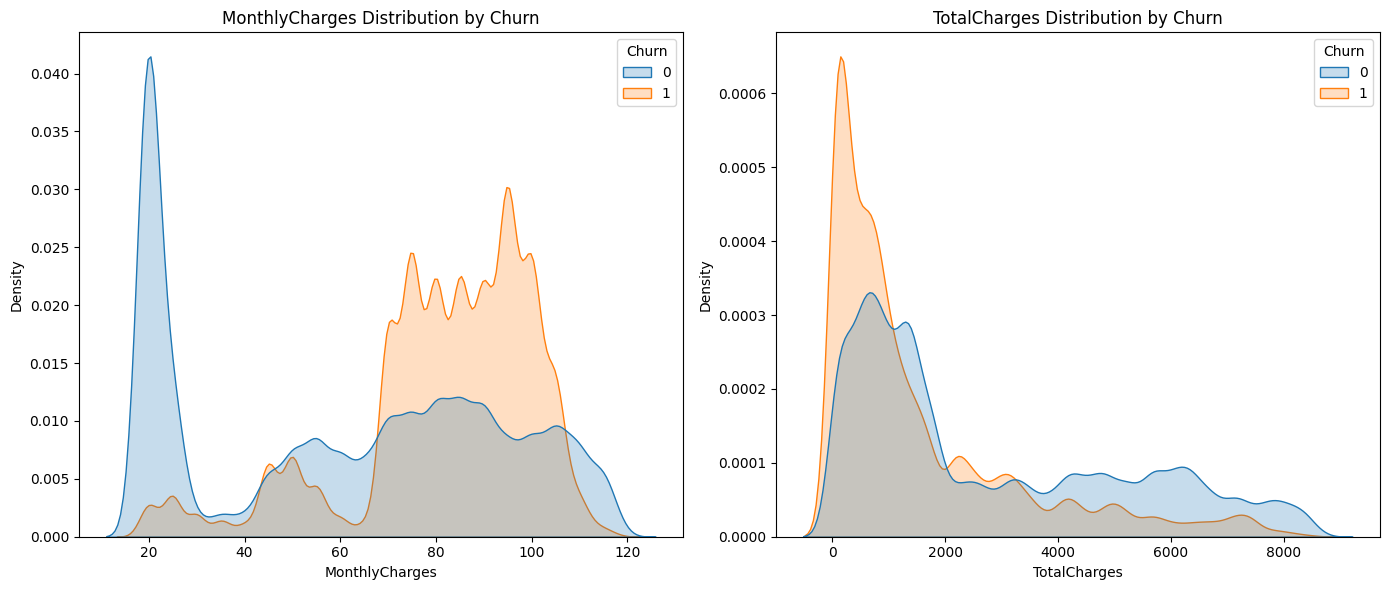

In [37]:
plt.figure(figsize=(14, 6))
for i, column in enumerate(numerical_cloumns):
    plt.subplot(1, 2, i + 1)
    sns.kdeplot(data=clean_df, x=column, hue='Churn', fill=True, common_norm=False)
    plt.title(f'{column} Distribution by Churn')
    plt.xlabel(column)
    plt.ylabel('Density')
plt.tight_layout()
plt.show()

Let's also look at the correlation coefficients between these numerical features and Churn.

# Analysis from the Above Graph :
1 Graph : Business interpretation:

High paying customers are likely on expensive fiber optic plans and feel it is not worth the cost
They are the most valuable customers AND the most likely to leave — which makes this a critical business problem

2 Graph : Business interpretation:

The first few months are the most dangerous period
If the company can retain a customer past a certain total charge threshold, they are likely to stay long term

In [38]:
for col in numerical_cloumns:
    correlation = clean_df[col].corr(clean_df['Churn'])
    print(f"Correlation between {col} and Churn: {correlation:.4f}")

Correlation between MonthlyCharges and Churn: 0.2730
Correlation between TotalCharges and Churn: -0.2184


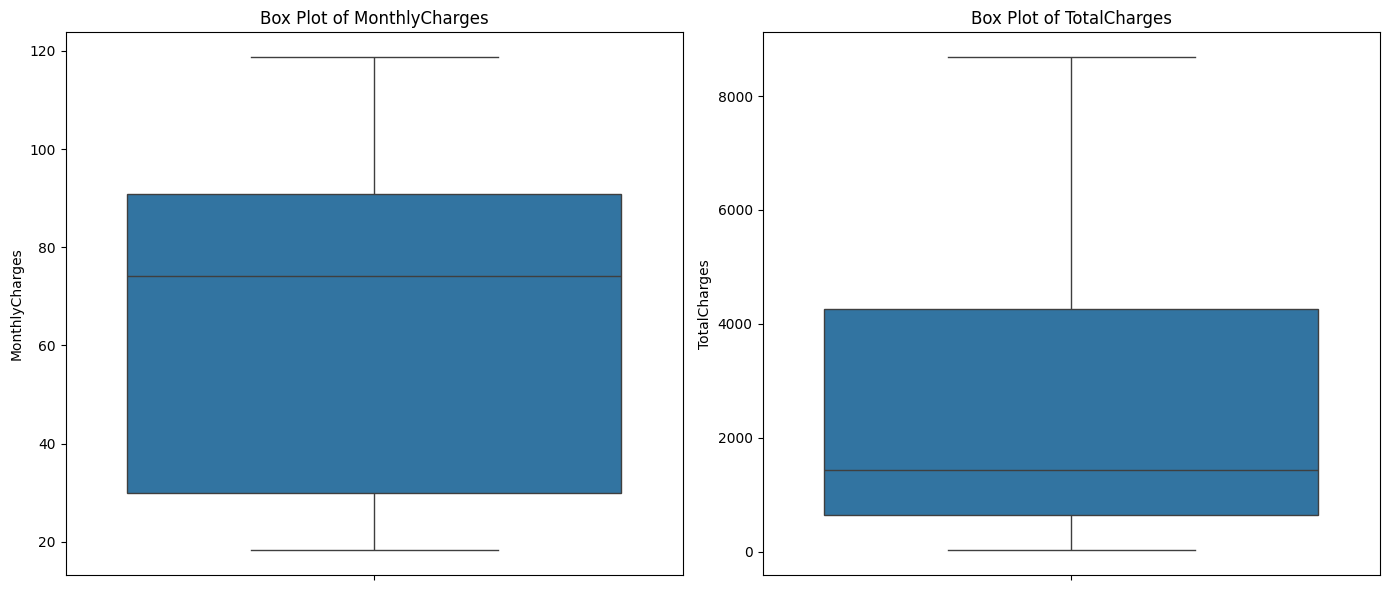

In [39]:
plt.figure(figsize=(14, 6))
for i, column in enumerate(numerical_cloumns):
    plt.subplot(1, 2, i + 1) # Arrange plots in 1 row, 2 columns
    sns.boxplot(y=clean_df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)
plt.tight_layout()
plt.show()

In [40]:
for col in numerical_cloumns:
    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = clean_df[(clean_df[col] < lower_bound) | (clean_df[col] > upper_bound)]

    print(f"\n--- Outliers for {col} ---")
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")
    if not outliers.empty:
        display(outliers[[col, 'Churn']].head())
    else:
        print("No outliers detected based on the IQR method.")


--- Outliers for MonthlyCharges ---
Q1: 29.90, Q3: 90.80, IQR: 60.90
Lower Bound: -61.45, Upper Bound: 182.15
Number of outliers: 0
No outliers detected based on the IQR method.

--- Outliers for TotalCharges ---
Q1: 639.65, Q3: 4263.80, IQR: 3624.15
Lower Bound: -4796.58, Upper Bound: 9700.03
Number of outliers: 0
No outliers detected based on the IQR method.


In [41]:
clean_df

,id,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,29,1,0,1,0,1,...,60.10,1653.85,0,0,0,1,0,0,0,1
1,1,0,1,1,58,1,0,1,1,0,...,69.50,3778.20,0,0,0,0,1,1,0,0
2,2,0,1,0,58,1,1,0,1,0,...,100.40,5841.35,0,1,0,0,0,0,1,0
3,3,0,0,0,1,1,0,0,0,0,...,69.70,70.70,1,1,0,0,0,0,1,0
4,4,0,0,0,1,1,0,0,0,0,...,70.45,70.45,1,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,594189,0,0,0,57,1,1,0,0,1,...,97.55,5460.70,0,1,0,0,1,0,0,0
594190,594190,0,0,0,72,1,1,1,1,1,...,91.95,6782.15,0,0,0,0,1,0,0,0
594191,594191,0,1,0,72,1,1,0,0,0,...,24.40,1871.90,0,0,1,0,1,1,0,0
594192,594192,0,0,0,32,1,1,0,0,0,...,86.00,2847.20,0,1,0,0,0,0,1,0


In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [43]:
decision_tree = DecisionTreeClassifier()
random_forest = RandomForestClassifier()
xgboost_model = XGBClassifier()

In [44]:
from imblearn.over_sampling import SMOTE

In [45]:
test_data=pd.read_csv('/content/drive/MyDrive/Kaggle Playground/test.csv')

In [46]:
X=clean_df.drop('Churn',axis=1)
y=clean_df['Churn']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

In [48]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score

# Mistake:

1. I performed EDA only on the train data but it should not be like that you have to perform EDA side by side simultaneoulsy both on the train_data and test_data so the columns dont differ .

2. I fitted the model on train_data after train_test_split and also predicted the model on basis of train_data but we should predict on train_data and test on test_data


### Step 1: Preprocessing `test_data` to match `train_data`

We need to apply the exact same preprocessing steps to the `test_data` that we applied to `train_data`. This includes:

-   Replacing 'No internet service' and 'No phone service' with 'No'.
-   Converting 'Yes'/'No' columns to 1/0.
-   Converting 'gender' to 1/0 and then dropping it (as it was dropped from `train_data`).
-   Applying one-hot encoding to `InternetService`, `Contract`, and `PaymentMethod`.
-   Converting `TotalCharges` to numeric and filling NaNs.
-   Converting boolean columns to int.

We'll also keep the original `id` column from `test_data` separate, as it's needed for the final submission but not for training the model.

In [49]:
# this is all done because my mistake was i did not performed same eda on the
# train data as well because we all have to perform eda both on train as well as
# test_data


test_data_processed = test_data.copy()

test_ids = test_data_processed['id']

test_data_processed.replace('No internet service', 'No', inplace=True)
test_data_processed.replace('No phone service', 'No', inplace=True)

yes_no_columns_test = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
                       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                       'StreamingMovies', 'PaperlessBilling']
for col in yes_no_columns_test:
    test_data_processed[col] = test_data_processed[col].apply(lambda x: 1 if x == 'Yes' else 0)

test_data_processed['gender'] = test_data_processed['gender'].apply(lambda x: 1 if x == 'Male' else 0)

test_data_processed = test_data_processed.drop(['gender', 'id'], axis=1)

categorical_cols_test = ['InternetService', 'Contract', 'PaymentMethod']
test_data_processed = pd.get_dummies(test_data_processed, columns=categorical_cols_test, drop_first=True)

test_data_processed['TotalCharges'] = pd.to_numeric(test_data_processed['TotalCharges'], errors='coerce')
test_data_processed['TotalCharges'].fillna(0, inplace=True)

bool_cols_test = test_data_processed.select_dtypes(include='bool').columns
test_data_processed[bool_cols_test] = test_data_processed[bool_cols_test].astype(int)

display(test_data_processed.head())
print(f"Shape of preprocessed test_data: {test_data_processed.shape}")

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,72,1,1,1,1,1,1,...,1,115.55,8061.50,1,0,0,1,0,1,0
1,0,1,0,71,1,0,0,0,0,0,...,0,19.80,1336.50,0,1,0,1,0,0,0
2,0,0,0,12,1,0,1,1,0,0,...,1,55.55,633.55,0,0,0,0,0,0,0
3,0,1,1,71,1,1,1,0,1,1,...,0,84.10,6457.15,0,0,0,1,1,0,0
4,0,0,0,15,1,0,1,0,0,0,...,0,90.35,1233.65,1,0,0,0,0,1,0


Shape of preprocessed test_data: (254655, 22)


In [50]:
X_train

,id,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
6165,6165,0,1,0,60,1,1,0,1,1,...,1,104.90,6273.40,1,0,0,0,0,1,0
565551,565551,1,0,0,47,1,1,0,1,0,...,0,74.40,3847.75,0,0,1,0,0,1,0
85537,85537,0,0,1,11,1,0,0,0,0,...,0,59.45,669.45,0,0,0,0,0,0,0
137025,137025,0,1,1,35,1,1,1,1,0,...,0,62.25,2460.55,0,0,1,0,0,0,0
436494,436494,0,0,0,56,1,0,0,0,1,...,1,94.50,5149.45,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317102,317102,0,1,1,28,0,0,0,1,1,...,1,53.80,1559.50,0,0,0,0,1,0,0
177194,177194,0,0,0,3,1,1,1,0,0,...,1,54.25,235.05,0,0,0,0,0,1,0
143737,143737,0,0,0,10,1,0,0,0,0,...,1,87.20,829.55,1,0,0,0,0,1,0
215738,215738,0,0,0,58,1,1,0,1,1,...,1,118.65,6521.90,1,0,0,1,1,0,0


### Step 2: Aligning Columns Between Processed Test Data and Training Data

It's crucial that the columns in our `test_data_processed` match exactly, in name and order, with the features used to train our model (`X_train_resampled_new`). One-hot encoding can sometimes create different numbers of columns if categories are missing in one dataset compared to the other. We need to ensure consistency.

We will add any missing columns to `test_data_processed` (filling them with zeros) and ensure the column order matches `X_train_resampled_new`.

In [51]:
# Removed global SMOTE application to apply it only to the training set after splitting.

### Step 3: Making Predictions and Generating Submission File

Now that `test_data_for_prediction` is correctly formatted, we can use our trained `random_forest_corrected` model to make predictions and create the `submission_corrected.csv` file.

# Dont train whole data at once 6 lakhs data to the computer can be overwheling

In [52]:
train_data['Churn'].value_counts()

,count
Churn,
0,460377
1,133817


In [53]:
churners = clean_df[clean_df['Churn'] == 1].sample(25000, random_state=42)
non_churners = clean_df[clean_df['Churn'] == 0].sample(25000, random_state=42)
train_data_sample = pd.concat([churners, non_churners])

# Ensure 'id' and 'gender' are dropped for training consistency
X = train_data_sample.drop(['Churn', 'id'], axis=1)
y = train_data_sample['Churn']

In [54]:
# y_train_smote.value_counts() # understood now our data is completely balanced
# y_train_data=y_train_smote.sample(25000,random_state=42)
# x_train_data=X_train_smote.sample(25000,random_state=42)
# df_to_train=pd.concat([x_train_data,y_train_data],axis=1)
# X=df_to_train.drop('Churn',axis=1)
# y=df_to_train['Churn']


In [55]:
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.33, random_state=42)

# Apply SMOTE only to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Shape of X_train after SMOTE: {X_train_smote.shape}")
print(f"Shape of y_train after SMOTE: {y_train_smote.shape}")
print(f"Value counts of y_train after SMOTE:\n{y_train_smote.value_counts()}")

Shape of X_train after SMOTE: (33562, 22)
Shape of y_train after SMOTE: (33562,)
Value counts of y_train after SMOTE:
Churn
1    16781
0    16781
Name: count, dtype: int64


In [56]:
model_xgboost=XGBClassifier(
                          n_jobs = 4,
                          objective='binary:logistic',
                          use_label_encoder = False
)
# Fit the model using the SMOTEd training data
model_xgboost.fit(X_train_smote,y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=4, num_parallel_tree=None, ...)

In [57]:
X_train_smote

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,5,1,1,0,0,0,0,...,1,94.100000,502.600000,1,0,0,0,0,1,0
1,0,0,0,16,1,0,0,1,0,0,...,0,73.350000,1245.050000,1,0,0,0,0,1,0
2,0,0,1,16,1,0,0,0,0,0,...,1,69.750000,1215.050000,1,0,0,0,0,1,0
3,1,0,0,18,1,1,0,0,1,0,...,1,101.350000,1667.750000,1,0,0,0,0,1,0
4,0,1,1,64,1,1,1,1,1,1,...,1,114.650000,7111.300000,1,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33557,0,0,0,11,1,1,0,0,1,0,...,1,100.746114,1046.823057,1,0,0,0,0,1,0
33558,1,0,0,1,1,1,0,0,0,0,...,1,95.821025,95.821025,1,0,0,0,0,1,0
33559,0,0,0,13,1,1,0,0,1,0,...,1,101.819389,1346.056213,1,0,0,0,0,1,0
33560,0,0,0,6,1,0,0,0,0,0,...,1,89.099212,552.833213,1,0,0,0,0,1,0


In [58]:
y_pred=model_xgboost.predict(X_test)
accuracy_score(y_pred,y_test)

0.8372727272727273

In [59]:
confusion_matrix(y_pred,y_test)

array([[6547, 1013],
       [1672, 7268]])

In [60]:
X

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
336077,0,0,0,9,1,0,0,0,0,0,...,1,89.60,851.30,1,0,0,0,0,1,0
103521,1,1,0,12,1,1,0,0,0,0,...,1,94.65,966.15,1,0,0,0,0,1,0
470947,0,0,0,2,1,1,0,1,0,0,...,1,90.85,132.10,1,0,0,0,0,1,0
167256,1,1,0,5,1,1,0,0,1,0,...,1,100.30,5283.95,1,0,0,0,0,1,0
179544,0,0,0,9,1,1,0,0,1,0,...,1,94.70,1023.95,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173356,0,1,1,18,1,0,0,0,0,0,...,1,45.40,683.25,0,0,0,0,0,1,0
74363,0,0,0,69,1,0,0,0,0,0,...,0,19.30,1377.85,0,1,0,1,0,0,1
186399,0,1,0,68,1,1,1,1,1,1,...,0,90.90,5893.95,0,0,0,1,1,0,0
359263,0,0,0,11,1,0,0,0,0,0,...,1,55.80,563.60,0,0,0,0,0,0,1


In [61]:
model_xgboost.fit(X,y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=4, num_parallel_tree=None, ...)

In [62]:
y_pred=model_xgboost.predict(X_test)
accuracy_score(y_pred,y_test)

0.8741212121212121

In [63]:
y.value_counts()

,count
Churn,
1,25000
0,25000


In [64]:
# Ensure the model is trained on the full balanced dataset for submission
# This step was already performed in cell '1Ny0eE3Yqulr' with model_xgboost.fit(X,y)
# We'll use this trained model to make predictions on the test_data_processed.

# Make predictions on the preprocessed test data
kaggle_predictions = model_xgboost.predict(test_data_processed)

# Create the submission DataFrame
submission_df = pd.DataFrame({'id': test_ids, 'Churn': kaggle_predictions})

# Display the first few rows of the submission DataFrame
display(submission_df.head())

# Save the submission file to CSV
submission_df.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully!")
submission_df.shape


,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,1


Submission file 'submission.csv' created successfully!


(254655, 2)

In [65]:
test_data_processed

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,72,1,1,1,1,1,1,...,1,115.55,8061.50,1,0,0,1,0,1,0
1,0,1,0,71,1,0,0,0,0,0,...,0,19.80,1336.50,0,1,0,1,0,0,0
2,0,0,0,12,1,0,1,1,0,0,...,1,55.55,633.55,0,0,0,0,0,0,0
3,0,1,1,71,1,1,1,0,1,1,...,0,84.10,6457.15,0,0,0,1,1,0,0
4,0,0,0,15,1,0,1,0,0,0,...,0,90.35,1233.65,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254650,0,1,1,72,1,0,0,0,0,0,...,0,19.95,1443.65,0,1,0,1,1,0,0
254651,1,1,0,16,1,1,0,0,0,1,...,1,100.15,1563.50,1,0,0,0,0,1,0
254652,0,1,0,35,1,1,1,0,1,1,...,1,105.80,3132.75,1,0,0,0,0,0,0
254653,0,0,0,25,1,0,0,0,0,0,...,1,20.25,511.25,0,1,0,1,1,0,0


# Trainging Data on Actual Data not 50,000 Samples


In [66]:
X=clean_df.drop(['Churn', 'id'],axis=1)
y=clean_df['Churn']

In [67]:
y.value_counts()

,count
Churn,
0,460377
1,133817


In [68]:
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.33, random_state=42)

In [69]:
y_train.value_counts()

,count
Churn,
0,308439
1,89670


In [70]:
X_sm,y_sm=smote.fit_resample(X_train,y_train)

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
   X_sm, y_sm, test_size=0.33, random_state=42,stratify=y_sm)

In [72]:
model_xgboost.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=4, num_parallel_tree=None, ...)

In [73]:
# y_pred=model_xgboost.predict(test_data_processed)
# accuracy_score(y_pred,y_test)

X_train

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
286474,0,1,0,72,1,1,1,1,1,1,...,1,84.200000,5528.900000,0,0,0,1,1,0,0
470582,0,1,1,7,1,1,0,0,0,0,...,1,98.941152,740.353589,1,0,0,0,0,1,0
173557,1,1,0,37,1,1,1,0,0,0,...,0,59.850000,1874.800000,0,0,0,0,0,1,0
388855,0,0,0,26,1,0,0,0,0,0,...,1,90.250000,2065.150000,1,0,0,0,0,0,0
142328,0,0,0,43,1,1,0,0,1,0,...,1,88.200000,4186.300000,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386331,0,1,1,67,1,1,1,1,1,1,...,0,85.400000,6293.200000,0,0,0,1,1,0,0
394951,0,1,1,25,1,0,0,0,0,0,...,0,20.450000,522.950000,0,1,1,0,0,0,1
445465,0,0,0,7,1,1,0,0,0,0,...,1,100.713482,673.142447,1,0,0,0,0,1,0
71243,0,1,0,33,1,1,0,0,0,0,...,1,94.700000,2984.550000,1,0,0,0,0,1,0


# Task
Train an XGBoost classification model for churn prediction using the full preprocessed training data (`clean_df`). This involves:
1. Creating feature set X and target variable y from `clean_df`, dropping the 'id' column from X.
2. Splitting X and y into training and testing sets (X_train, X_test, y_train, y_test) using an 80/20 split and stratified sampling.
3. Applying SMOTE to X_train and y_train to handle class imbalance, resulting in X_train_smote and y_train_smote.
4. Training an XGBoost Classifier on the SMOTE-balanced training data.
5. Evaluating the model's performance on the test set using accuracy, confusion matrix, and classification report.
6. Using the trained model to predict churn on the preprocessed `test_data_processed` and generating a `submission.csv` file with the predictions and original 'id' column.

## Prepare Full Training Features and Target

### Subtask:
Create the final feature set X and target variable y from clean_df. Ensure the id column is dropped from X as it's not a feature for model training, and the Churn column becomes y.


## Split Data into Training and Testing Sets

### Subtask:
Split the full feature set X and target variable y into training and testing sets (X_train, X_test, y_train, y_test) using an 80/20 split and stratified sampling.


**Reasoning**:
The subtask requires splitting the full feature set `X` and target `y` into training and testing sets with an 80/20 ratio and stratified sampling. This will be done using the `train_test_split` function with the specified parameters and then printing the shapes to verify the split.



In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (475355, 22)
Shape of X_test: (118839, 22)
Shape of y_train: (475355,)
Shape of y_test: (118839,)


## Apply SMOTE to Training Data

### Subtask:
Apply SMOTE (Synthetic Minority Over-sampling Technique) to `X_train` and `y_train` to handle the class imbalance. This will create a balanced training set for model training.

### Instructions:
1. Initialize the SMOTE object.
2. Apply SMOTE to `X_train` and `y_train`, storing the results in `X_train_smote` and `y_train_smote`.
3. Print the shapes of the new SMOTE-balanced training data and the value counts of `y_train_smote` to verify the balancing.

**Reasoning**:
Now, apply SMOTE to the training data to address class imbalance, as per the new subtask instructions. This involves initializing SMOTE, fitting and transforming the training data, and then verifying the balance.



In [75]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Shape of X_train after SMOTE: {X_train_smote.shape}")
print(f"Shape of y_train after SMOTE: {y_train_smote.shape}")
print(f"Value counts of y_train after SMOTE:\n{y_train_smote.value_counts()}")

Shape of X_train after SMOTE: (736602, 22)
Shape of y_train after SMOTE: (736602,)
Value counts of y_train after SMOTE:
Churn
0    368301
1    368301
Name: count, dtype: int64


## Train XGBoost Classifier

### Subtask:
Train an XGBoost Classifier on the SMOTE-balanced training data (`X_train_smote`, `y_train_smote`).

### Instructions:
1. Initialize an `XGBClassifier` with appropriate parameters (e.g., `n_jobs=4`, `objective='binary:logistic'`, `use_label_encoder=False`).
2. Fit the model using `X_train_smote` and `y_train_smote`.

**Reasoning**:
Now, train an XGBoost Classifier using the balanced training data, following the instructions provided in the subtask.



In [76]:
model_xgboost.fit(X_train_smote, y_train_smote)

print("XGBoost Classifier trained successfully on SMOTE-balanced data.")

XGBoost Classifier trained successfully on SMOTE-balanced data.


## Evaluate Model Performance

### Subtask:
Evaluate the trained XGBoost Classifier's performance on the test set (`X_test`, `y_test`) using accuracy, confusion matrix, and classification report.

### Instructions:
1. Make predictions on `X_test` using the trained `model_xgboost`.
2. Calculate and print the accuracy score.
3. Generate and print the confusion matrix.
4. Generate and print the classification report.

**Reasoning**:
Now, evaluate the trained XGBoost model's performance on the test set by making predictions and then calculating and printing the accuracy score, confusion matrix, and classification report, as outlined in the subtask.



In [77]:
y_pred = model_xgboost.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.83783101507081

Confusion Matrix:
 [[78918 13158]
 [ 6114 20649]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.86      0.89     92076
           1       0.61      0.77      0.68     26763

    accuracy                           0.84    118839
   macro avg       0.77      0.81      0.79    118839
weighted avg       0.86      0.84      0.84    118839



## Make Predictions on Test Data and Generate Submission File

### Subtask:
Use the trained `model_xgboost` to make predictions on the preprocessed `test_data_processed` and generate a `submission.csv` file with the predictions and original 'id' column.

### Instructions:
1. Ensure that the columns in `test_data_processed` match the columns (and their order) used during model training (`X_train_smote`). If there are discrepancies, align them (e.g., add missing columns to `test_data_processed` and fill with zeros).
2. Make predictions on `test_data_processed` using `model_xgboost.predict()`.
3. Create a pandas DataFrame for submission with 'id' from `test_ids` and 'Churn' from the predictions.
4. Save the submission DataFrame to a CSV file named `submission.csv`, without the index.

**Reasoning**:
Before making predictions, it's crucial to ensure that the columns in `test_data_processed` are exactly the same and in the same order as the features the model was trained on (`X_train_smote`). This step aligns the columns, adds any missing ones (filling with 0), and then proceeds to make predictions and generate the submission file, as requested by the subtask.



In [78]:
training_columns = X_train_smote.columns
test_data_for_prediction = test_data_processed.reindex(columns=training_columns, fill_value=0)

kaggle_predictions = model_xgboost.predict(test_data_for_prediction)

submission_df = pd.DataFrame({'id': test_ids, 'Churn': kaggle_predictions})

display(submission_df.head())

submission_df.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully!")

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0


Submission file 'submission.csv' created successfully!


In [79]:
kaggle_predictions.shape

(254655,)

In [106]:
from lightgbm import LGBMClassifier
lightbgm_model=LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42)

In [107]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(tree_method='hist', device="cuda", random_state=42), # Use 'hist' for speed!
    "LightGBM": lightbgm_model
}

In [86]:
results=[]

In [101]:
from sklearn.model_selection import cross_val_score

In [109]:
import warnings
warnings.filterwarnings('ignore')
for model_name, model in models.items():
  print('Training on ', model_name)
  scores=cross_val_score(model,X_sm,y_sm,cv=5,scoring='roc_auc',n_jobs=-1)
  results.append(scores)
  print({model_name}, 'Mean AUC_ROC: ', {np.mean(scores)})

Training on  Decision Tree
{'Decision Tree'} Mean AUC_ROC:  {np.float64(0.8494511610797243)}
Training on  Random Forest
{'Random Forest'} Mean AUC_ROC:  {np.float64(0.9529470715076245)}
Training on  XGBoost
{'XGBoost'} Mean AUC_ROC:  {np.float64(0.950064506101328)}
Training on  LightGBM
{'LightGBM'} Mean AUC_ROC:  {np.float64(0.950010040939928)}


In [98]:
y_sm.value_counts()


,count
Churn,
0,308439
1,308439


In [112]:
best_model=RandomForestClassifier(n_jobs=-1, random_state=42,max_depth=100,n_estimators=100,min_samples_leaf=5)
best_model.fit(X_sm, y_sm)

RandomForestClassifier(max_depth=100, min_samples_leaf=5, n_jobs=-1,
                       random_state=42)

In [113]:
y_pred=best_model.predict(test_data_for_prediction)

In [120]:
test_ids=test_data['id']

In [123]:
rfc_probs = best_model.predict_proba(test_data_processed)[:, 1]

submission = pd.DataFrame({
    'id': test_ids,
    'Churn': rfc_probs
})

submission = pd.DataFrame({
    'id': test_ids,
    'Churn': rfc_probs
})

submission.to_csv('submission_rfc.csv', index=False)
print("file  created!")

file  created!


In [124]:
submission.shape

(254655, 2)